# L4 – Algoritmos de clusterización con Iris

En este notebook aplicamos y comparamos tres algoritmos de clusterización sobre el dataset **Iris** (sin usar la etiqueta de especie):

1. K-Means
2. Agrupamiento Jerárquico
3. DBSCAN

Además, calculamos el coeficiente de silueta como métrica de validación.


In [1]:
# 1. Cargar librerías y configurar entorno

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

plt.style.use('seaborn-v0_8')
RANDOM_STATE = 42

## 2. Cargar el dataset Iris sin la variable de clase

En este paso cargamos Iris y armamos un DataFrame solo con las variables numéricas (sin la etiqueta de especie).

In [2]:
# 2. Cargar dataset Iris

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)  # solo variables numéricas

# Guardamos la clase real aparte (solo para análisis, NO para entrenar)
y_true = iris.target

print('Dimensiones de X:', X.shape)
X.head()

Dimensiones de X: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 3. K-Means: ajuste, visualización y comentarios

K-Means busca dividir los datos en *k* grupos, minimizando la distancia de cada punto a su centroide.


In [3]:
# 3.1 Aplicar K-Means con 3 clusters

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X)

X['kmeans_cluster'] = kmeans_labels
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),kmeans_cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


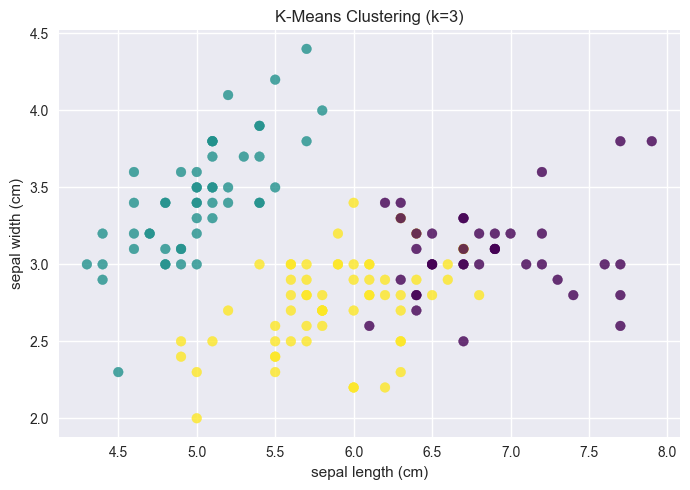

In [4]:
# 3.2 Visualización 2D de K-Means (usando las dos primeras features)

plt.figure(figsize=(7, 5))
plt.scatter(
    X.iloc[:, 0],  # sepal length
    X.iloc[:, 1],  # sepal width
    c=X['kmeans_cluster'],
    cmap='viridis',
    alpha=0.8
)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('K-Means Clustering (k=3)')
plt.tight_layout()
plt.show()

## 4. Agrupamiento Jerárquico: dendrograma y clusters

El agrupamiento jerárquico construye una jerarquía de fusiones entre puntos y grupos. El dendrograma ayuda a decidir cuántos clusters elegir.

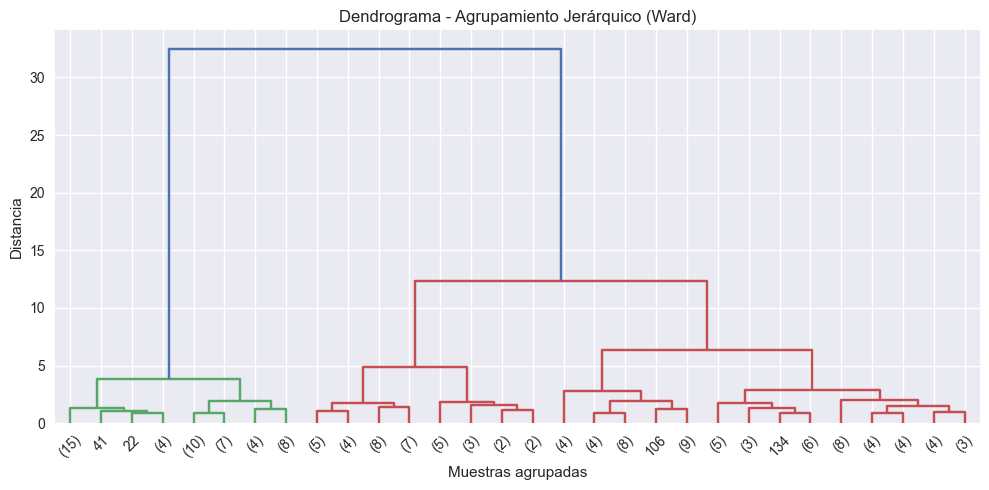

In [5]:
# 4.1 Dendrograma - Agrupamiento Jerárquico (método Ward)

linked = linkage(X.iloc[:, :4], method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title('Dendrograma - Agrupamiento Jerárquico (Ward)')
plt.xlabel('Muestras agrupadas')
plt.ylabel('Distancia')
plt.tight_layout()
plt.show()

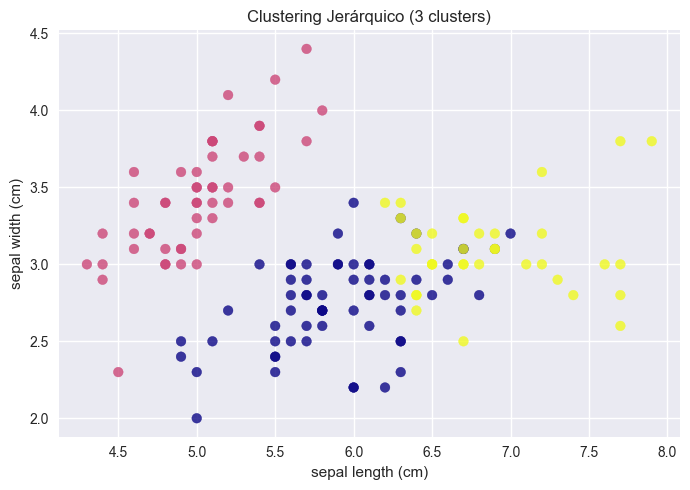

In [6]:
# 4.2 Aplicar AgglomerativeClustering (3 clusters) y visualizar

agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
agglo_labels = agglo.fit_predict(X.iloc[:, :4])

X['agglo_cluster'] = agglo_labels

plt.figure(figsize=(7, 5))
plt.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=X['agglo_cluster'],
    cmap='plasma',
    alpha=0.8
)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('Clustering Jerárquico (3 clusters)')
plt.tight_layout()
plt.show()

## 5. DBSCAN: clusters por densidad y ruido

DBSCAN agrupa puntos que están densamente conectados y marca como ruido aquellos que no pertenecen a ninguna región densa.

Es sensible a la escala de las variables, por eso primero estandarizamos.


In [7]:
# 5.1 Escalado para DBSCAN

scaler = StandardScaler()
X_scaled_db = scaler.fit_transform(X.iloc[:, :4])  # solo las 4 features originales

In [8]:
# 5.2 Aplicar DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled_db)

X['dbscan_cluster'] = dbscan_labels

print('Conteo de etiquetas DBSCAN:')
print(X['dbscan_cluster'].value_counts())

Conteo de etiquetas DBSCAN:
dbscan_cluster
 1    71
 0    45
-1    34
Name: count, dtype: int64


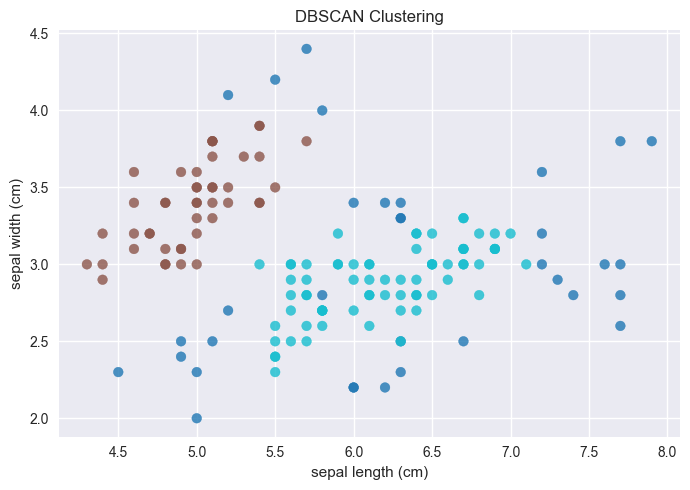

In [9]:
# 5.3 Visualización 2D de DBSCAN

plt.figure(figsize=(7, 5))
plt.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=X['dbscan_cluster'],
    cmap='tab10',
    alpha=0.8
)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('DBSCAN Clustering')
plt.tight_layout()
plt.show()

## 6. Plus: comparar con coeficiente de silueta

El coeficiente de silueta mide qué tan bien definidos están los clusters (valores cercanos a 1 indican mejor separación).

In [10]:
# 6.1 Función auxiliar para calcular silueta de forma segura

def silueta_segura(X_data, labels):
    labels = np.array(labels)
    labels_unique = np.unique(labels)
    # Necesitamos al menos 2 clusters distintos
    if len(labels_unique) < 2:
        return None
    # Si hay muchos -1 (ruido), usamos solo puntos que no son ruido
    mask = labels != -1
    if mask.sum() < 2 or len(np.unique(labels[mask])) < 2:
        return None
    return silhouette_score(X_data[mask], labels[mask])

# Estandarizamos todas las features para comparar
X_scaled_all = StandardScaler().fit_transform(X.iloc[:, :4])

sil_kmeans = silueta_segura(X_scaled_all, X['kmeans_cluster'].values)
sil_agglo  = silueta_segura(X_scaled_all, X['agglo_cluster'].values)
sil_dbscan = silueta_segura(X_scaled_all, X['dbscan_cluster'].values)

print('Coeficiente de silueta:')
print(' - K-Means    :', sil_kmeans)
print(' - Jerárquico :', sil_agglo)
print(' - DBSCAN     :', sil_dbscan)

Coeficiente de silueta:
 - K-Means    : 0.4472199222829889
 - Jerárquico : 0.45003062405768823
 - DBSCAN     : 0.6558885287002016


## 7. Conclusión: ¿qué método se adapta mejor a Iris?

En este dataset:

1. **K-Means** suele formar 3 clusters compactos y relativamente esféricos, alineados con las especies de Iris, por lo que suele funcionar muy bien.
2. **Agrupamiento jerárquico (Ward)** produce clusters similares a K-Means y el dendrograma ofrece una visión jerárquica útil para explorar el número de grupos.
3. **DBSCAN** depende mucho de `eps` y `min_samples`; con los parámetros usados, puede identificar menos clusters y marcar algunos puntos como ruido, porque la estructura de Iris no está tan basada en densidades muy separadas.

El coeficiente de silueta ayuda a cuantificar esta intuición: K-Means y el agrupamiento jerárquico tienden a obtener valores de silueta mayores que DBSCAN en este caso.
